The notebook contains three ML models for landslide susceptibility mapping: Random Forest (RF), Logistic Regression (LR) and Support Vector Machine (SVM) without climate variables (Predictor Set I)

In [11]:
import numpy as np

# Add this only if NumPy doesn't have find_common_type (NumPy 2.0+)
if not hasattr(np, "find_common_type"):
    def _find_common_type(array_types, scalar_types=None):
        """
        Simple replacement for the old np.find_common_type
        that works for how pyspatialml uses it.
        pyspatialml calls: np.find_common_type(self.dtypes, [])
        So we can just use np.result_type on the array dtypes.
        """
        if array_types is None:
            array_types = []
        # pyspatialml only passes dtypes here, scalar_types is []
        return np.result_type(*array_types)

    np.find_common_type = _find_common_type


In [1]:
from pyspatialml import Raster
import os
import matplotlib.pyplot as plt
import geopandas
import pandas as pd
import seaborn as sn
import rasterio.plot
import numpy as np
import matplotlib as mpl
import os
import geopandas as gpd
import numpy as np
from tempfile import NamedTemporaryFile
import warnings
warnings.filterwarnings('ignore')

Setting up the working directory:

In [2]:
os.chdir('C:/Flood Data/Flood Factors/Resample_Factors')

Loading the preprocessed landslide presence/absebce points

In [3]:
data=pd.read_csv('Flood_extractvalues_New_duplicate.csv')

In [4]:
data=data.drop(columns=['Mean_RX3day_Rainfall'])

In [5]:
data.head()

,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density,Class
0,288.434937,1676.0,7.209121,-1.024000,0.256000,73.709358,1459.744751,0.280242,17.0,0.496815,4.593312,2.0,9.0,-0.417748,372.050568,0.472717,0
1,234.865814,1697.0,44.725231,0.828993,-1.731007,73.811371,1444.912109,0.186464,16.0,5.206606,5.174378,2.0,7.0,-0.446055,2353.054443,0.187682,0
2,60.592812,3803.0,32.266174,-0.827077,0.452923,81.329865,1692.825928,0.092385,9.0,4.428362,4.371922,1.0,9.0,-0.523274,744.101135,0.318078,0
3,338.198578,1899.0,37.013485,-0.640000,0.640000,80.411331,1597.987915,0.204164,17.0,5.807874,2.808194,2.0,16.0,-0.768516,372.050568,0.403678,0
4,354.093872,4167.0,49.387146,-0.680899,-0.040899,96.287956,1899.889404,0.012031,20.0,3.683581,3.470599,1.0,14.0,0.049714,1663.860718,0.276737,0


In [6]:
data.describe()

,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density,Class
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,178.826617,2027.511785,21.833692,-0.063221,0.068227,80.848200,1606.805118,0.160585,15.572391,2.785065,5.696693,1.811448,11.855219,-0.351580,755.849181,0.368654,0.494949
std,95.529164,1215.681369,14.561834,1.152774,1.060527,12.376830,224.865355,0.112481,3.160511,3.291493,2.274942,0.719988,4.035641,0.225494,677.035529,0.163862,0.500818
min,-1.000000,494.000000,0.000000,-10.240000,-4.690824,38.070221,944.073303,-0.074921,9.000000,-11.212821,2.056899,1.000000,1.000000,-0.793756,0.000000,0.000000,0.000000
25%,96.009003,936.000000,8.984877,-0.640000,-0.480000,74.048729,1462.186279,0.074466,12.000000,1.949905,4.350558,1.000000,9.000000,-0.546507,372.050568,0.249398,0.000000
50%,184.899094,1692.000000,20.188250,-0.088615,0.000000,80.255363,1586.665039,0.149695,16.000000,3.287170,5.159569,2.000000,11.000000,-0.363007,526.158936,0.403678,0.000000
75%,249.676865,2889.000000,31.978168,0.537600,0.578462,87.662811,1769.321655,0.225501,17.000000,4.510977,6.407440,2.000000,16.000000,-0.184252,1116.151611,0.493859,1.000000
max,357.563354,4857.000000,59.550037,5.120000,9.702400,118.075333,2262.140381,0.544761,21.000000,11.321247,18.858854,4.000000,16.000000,0.117029,3200.500000,0.665181,1.000000


Dropping columns with climate data

In [7]:
#data= data.drop(columns=['average_temp_ref', 'cloudburst_ref', 'groundwater_ref', 'rain_average_ref', 'rain_max_day_ref'])

In [8]:
predictors = ['Aspect.tif', 'Elevation.tif',  'Slope.tif', 'Profile_curvature.tif', 'Plan_curvature.tif', 'Mean_RX1day_Rainfall.tif', 'Mean_Annual_Rainfall.tif', 'NDVI.tif', 'LULC.tif', 'SPI.tif', 'TWI.tif', 'Soil.tif','Geology.tif','NDWI.tif','Distance_from_streams.tif','Drainage_Density.tif']

making a raster stack out of predictors

In [9]:
stack = Raster(predictors)

In [10]:
stack.names

dict_keys(['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature', 'Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI', 'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams', 'Drainage_Density'])

Plotting variables

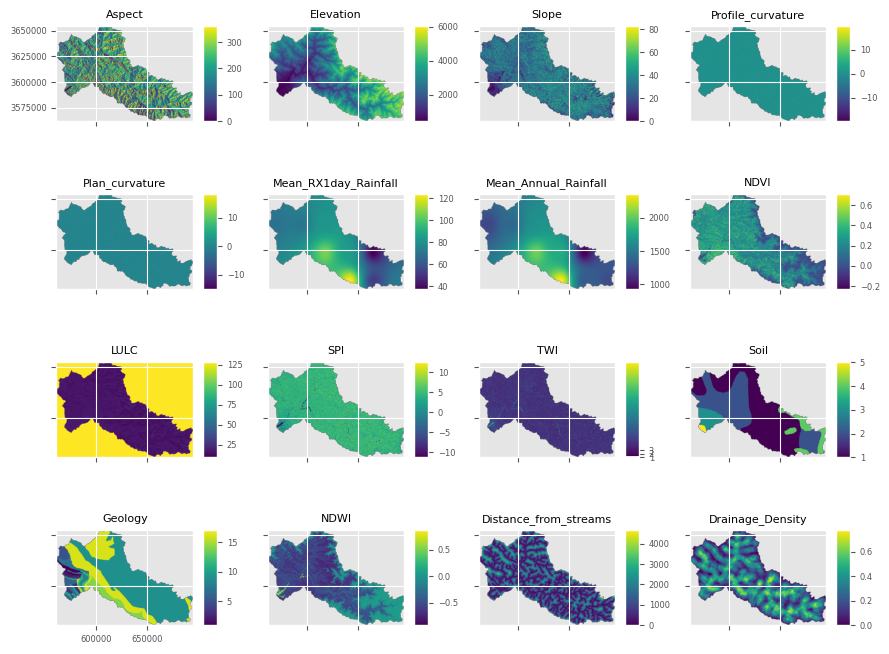

In [11]:
mpl.style.use('ggplot')
axs = stack.plot(figsize=(9, 7))
ax = axs.flatten()[10]
im = ax.images
im[0].colorbar.set_ticks([1,2,3])
ax = axs.flatten()[8]
ax.tick_params(axis='x', labelrotation=65)

plt.tight_layout()
plt.show()

In [12]:
#stack = stack.intersect() - if variables have different extent

Importing packages for Machine Learning

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

In [14]:
#####    Index value identification ###########
soil_idx = list(stack.names).index("Soil")
LULC_idx = list(stack.names).index("LULC")
Geology_idx = list(stack.names).index("Geology")
# prequaternary_idx = list(stack.names).index("prequaternary")
#print(soil_idx, geomorphology_idx, underground_idx, prequaternary_idx)
print(soil_idx,LULC_idx,Geology_idx)

11 8 12


In [15]:
#index of categorical features from the dataset
categorical_features = [11,8,12] # 'LULC', 'geomorphology', 'underground', 'prequarternary'

In [16]:
#index of numerical features from the dataset
numerical_features = [0, 1, 2, 3, 4, 5,6,7,9,10,13,14,15]   #'dem_elevation', 'TWI', 'TPI', 'TRI', 'SPI', 'easterness', 'northerness', 'slope_std', 'distance_coast', 'distance_streams'

In [17]:
preprocessor = ColumnTransformer([
    ('ohe_soil', OneHotEncoder(categories='auto', handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)])

Separating features from class labels

In [18]:
X = data.loc[:, stack.names]

In [19]:
X[:3]

,Aspect,Elevation,Slope,Profile_curvature,Plan_curvature,Mean_RX1day_Rainfall,Mean_Annual_Rainfall,NDVI,LULC,SPI,TWI,Soil,Geology,NDWI,Distance_from_streams,Drainage_Density
0,288.434937,1676.0,7.209121,-1.024000,0.256000,73.709358,1459.744751,0.280242,17.0,0.496815,4.593312,2.0,9.0,-0.417748,372.050568,0.472717
1,234.865814,1697.0,44.725231,0.828993,-1.731007,73.811371,1444.912109,0.186464,16.0,5.206606,5.174378,2.0,7.0,-0.446055,2353.054443,0.187682
2,60.592812,3803.0,32.266174,-0.827077,0.452923,81.329865,1692.825928,0.092385,9.0,4.428362,4.371922,1.0,9.0,-0.523274,744.101135,0.318078


Our labels

In [20]:
y = data["Class"]

In [21]:
y[:3]

0    0
1    0
2    0
Name: Class, dtype: int64

Splitting our data into a training (70% of the data) and a testing set (30%), stratified after classes, so that we get the same amount of landslide and non-landslide samples in both sets. Random_sate= 42 for reproducebility

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Checking the number of points in testing and training data

In [23]:
X_train.shape

(207, 16)

In [24]:
X_test.shape

(90, 16)

In [25]:
print("Columns in data:", data.columns)
print("Columns in stack:", stack.names)


Columns in data: Index(['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature',
       'Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI',
       'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams',
       'Drainage_Density', 'Class'],
      dtype='object')
Columns in stack: dict_keys(['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature', 'Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI', 'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams', 'Drainage_Density'])


## Random Forest model

In [37]:
# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(accuracy_score)

In [38]:
# Create the  grid for hyperparametertuning
grid_rf = {'classifier__n_estimators': [100, 200, 300, 400, 500, 600, 700, 800],
           'classifier__max_features': ['auto', 'sqrt', 'log2']}
print(grid_rf)

{'classifier__n_estimators': [100, 200, 300, 400, 500, 600, 700, 800], 'classifier__max_features': ['auto', 'sqrt', 'log2']}


In [39]:
# Create a classifier
rf = RandomForestClassifier(random_state=42)

 "Pipeline" is for making workflow with standardization and classification in a few lines of code

In [40]:
rf_flow = Pipeline([
    ('preproc', preprocessor),
    ('classifier', rf)
])

In [41]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import GridSearchCV

In [42]:
# Instantiate the grid search model with 10-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
model_rf = GridSearchCV(rf_flow, param_grid = grid_rf, cv = kfold, scoring=acc_scorer)

In [43]:
model_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_features': ['auto', 'sqrt', ...], 'classifier__n_estimators': [100, 200, ...]}"
,scoring,make_scorer(a...hod='predict')
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe_soil', ...), ('num', ...)]"


Best parameters from the grid search

In [44]:
model_rf.best_params_

{'classifier__max_features': 'log2', 'classifier__n_estimators': 200}

Using the test data for prediction

In [45]:
y_pred_rf = model_rf.predict(X_test)

Printing classification report

In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf, target_names = ['non-flood', 'flood']))

              precision    recall  f1-score   support

   non-flood       0.96      0.96      0.96        45
       flood       0.96      0.96      0.96        45

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



In [47]:
from sklearn.metrics import roc_auc_score
# Get probabilities for the positive class (flood)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("AUC Score (Random Forest):", round(auc_rf, 3))


AUC Score (Random Forest): 0.991


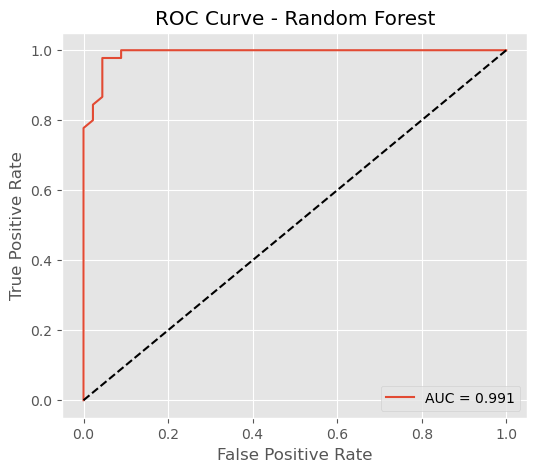

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_rf:.3f}')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()


In [49]:
# result_RF= stack.predict_proba(model_rf)

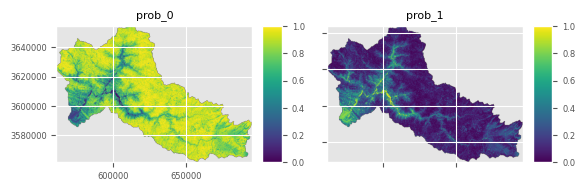

In [50]:
#result_RF.plot()
plt.show()

In [51]:
result_RF.write("C:/Flood Data/Susceptibility Maps/probability_R.F_newww.tif")

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [C:/Flood Data/Susceptibility Maps/probability...
2        rows                                               7442
3        cols                                              10699
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


Printing confusion matrix

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
print(confusion_matrix(y_test, y_pred_rf))
plt.show()

[[41  4]
 [ 3 42]]


Doing it in a better visual way

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

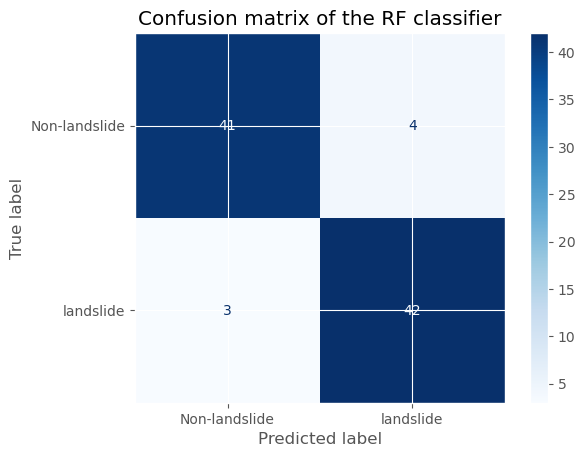

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, 
                                        cmap="Blues", 
                                        display_labels=["Non-landslide", "landslide"])

plt.title('Confusion matrix of the RF classifier')
plt.show()

Printing overall accuracy (all the correctly classified samples divided by the total number of samples)

In [56]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred_rf))

0.9222222222222223


Checking how our model is different from a classification created by a random process

In [57]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, y_pred_rf))

0.8444444444444444


Plotting ROC_AUC

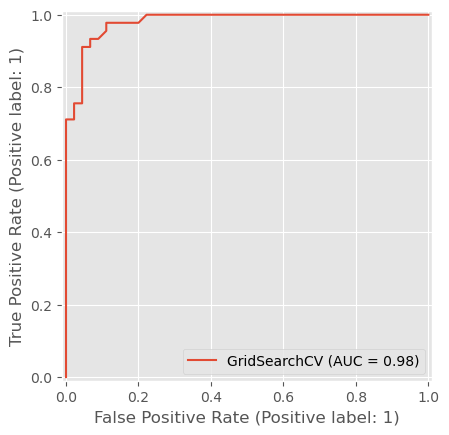

In [58]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model_rf, X_test, y_test)  
plt.show()

## Support Vector Machine model

In [81]:
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

In [82]:
param_grid_SVM = [
  {'classifier__C': [0.001, 0.1, 1, 10], 'classifier__gamma': [1, 0.1, 0.01,0.001, 0.0001, 'scale', 'auto'], 'classifier__kernel': ['rbf']},
 ]


In [83]:
# Create a model
svm = SVC(probability=True, random_state=42)

svm_flow = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('preproc', preprocessor),
    ('classifier', svm)
])

# Instantiate the grid search model with 10-fold cross-validation
inner = KFold(n_splits=10, shuffle=True, random_state=42)
model_svm = GridSearchCV(svm_flow, param_grid = param_grid_SVM, cv = inner, scoring=acc_scorer)


# Fit the grid search to the data
model_svm.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier__C': [0.001, 0.1, ...], 'classifier__gamma': [1, 0.1, ...], 'classifier__kernel': ['rbf']}]"
,scoring,make_scorer(a...hod='predict')
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [84]:
model_svm.best_params_

{'classifier__C': 1, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}

In [85]:
y_pred_svm = model_svm.predict(X_test)

In [86]:
print(classification_report(y_test, y_pred_svm, target_names = ['non-flood', 'flood']))


               precision    recall  f1-score   support

non-landslide       0.95      0.93      0.94        45
    landslide       0.93      0.96      0.95        45

     accuracy                           0.94        90
    macro avg       0.94      0.94      0.94        90
 weighted avg       0.94      0.94      0.94        90



In [65]:
#result_svm = stack.predict_proba(estimator=model_svm)

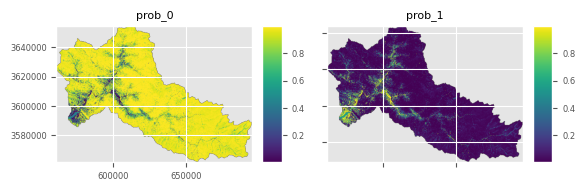

In [66]:
result_svm.plot()
plt.show()

In [68]:
result_svm.write("C:/Flood Data/Susceptibility Maps/SVM.tif")

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [C:/Flood Data/Susceptibility Maps/SVM.tif, C:...
2        rows                                               7442
3        cols                                              10699
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


## Logistic Regression model

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
param_grid_lr = [
  {'classifier__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'classifier__solver': ['liblinear'], 'classifier__penalty': ['l1','l2']},
  {'classifier__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'classifier__solver': ['lbfgs'], 'classifier__penalty': ['l2']},
 ]

In [90]:
lr = LogisticRegression(random_state=42) 
# Instantiate the grid search model

lr_flow = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('preproc', preprocessor),
    ('classifier', lr)
])

# Instantiate the grid search model with 10-fold cross-validation
# Instantiate the grid search model with 10-fold cross-validation
inner = KFold(n_splits=10, shuffle=True, random_state=42)

model_lr = GridSearchCV(lr_flow, param_grid = param_grid_lr, cv = inner, scoring=acc_scorer)


# Fit the grid search to the data
model_lr.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier__C': [0.0001, 0.001, ...], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}, {'classifier__C': [0.0001, 0.001, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}]"
,scoring,make_scorer(a...hod='predict')
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [91]:
model_lr.best_params_

{'classifier__C': 10,
 'classifier__penalty': 'l2',
 'classifier__solver': 'liblinear'}

Creating the final LR classifier with the found hyperparameters

In [92]:
y_pred_lr = model_lr.predict(X_test)

In [93]:
print(classification_report(y_test, y_pred_lr, target_names = ['non-landslide', 'landslide']))

               precision    recall  f1-score   support

non-landslide       0.98      0.93      0.95        45
    landslide       0.94      0.98      0.96        45

     accuracy                           0.96        90
    macro avg       0.96      0.96      0.96        90
 weighted avg       0.96      0.96      0.96        90



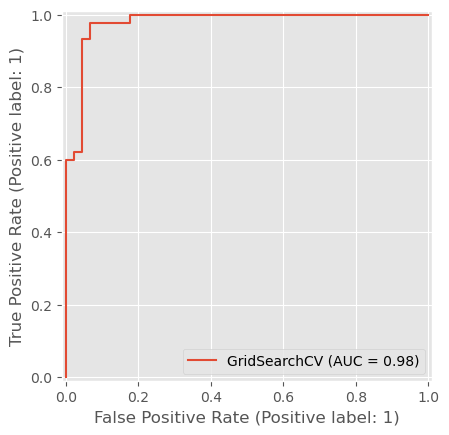

In [94]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model_lr, X_test, y_test)  
plt.show()

In [78]:
result_lr = stack.predict_proba(estimator=model_lr)

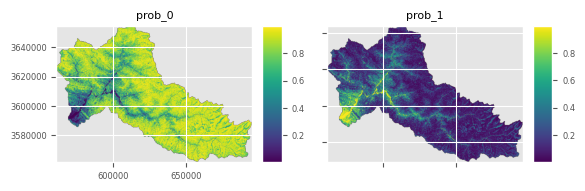

In [79]:
result_lr.plot()
plt.show()

In [81]:
result_lr.write(r"C:/Flood Data/Susceptibility Maps/probability_lr_without_climate_variables.tif")

Raster Object Containing 2 Layers
    attribute                                             values
0       names                                   [prob_0, prob_1]
1       files  [C:/Flood Data/Susceptibility Maps/probability...
2        rows                                               7442
3        cols                                              10699
4         res                                       (12.5, 12.5)
5  nodatavals  [-3.4028234663852886e+38, -3.4028234663852886e...


## Ann Model

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AUC (CV): 0.9838775510204082
Best Parameters:
  ann__learning_rate_init: 0.0001
  ann__hidden_layer_sizes: (32,)
  ann__batch_size: 32
  ann__alpha: 0.0001
  ann__activation: relu

Classification Report (Test):
              precision    recall  f1-score   support

   non-flood       0.93      0.91      0.92        45
       flood       0.91      0.93      0.92        45

    accuracy                           0.92        90
   macro avg       0.92      0.92      0.92        90
weighted avg       0.92      0.92      0.92        90

Test AUC: 0.9846913580246913


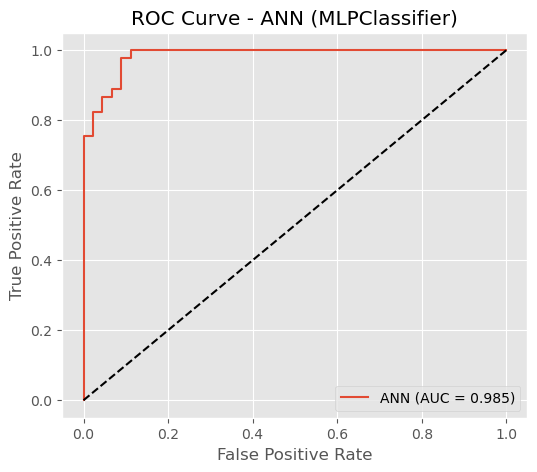

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# 1. Define pipeline with IMPUTER + SCALER + ANN
pipe_ann = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # or "mean"
    ("scaler", StandardScaler()),
    ("ann", MLPClassifier(max_iter=1000, random_state=42))
])

# -----------------------------
# 2. Define hyperparameter search space
# -----------------------------
param_dist = {
    'ann__hidden_layer_sizes': [
        (32,), (64,), (128,),
        (64, 32), (128, 64)
    ],
    'ann__activation': ['relu', 'tanh'],
    'ann__alpha': [1e-5, 1e-4, 1e-3],        # L2 regularization
    'ann__learning_rate_init': [1e-4, 5e-4, 1e-3],
    'ann__batch_size': [16, 32, 64]
}

# -----------------------------
# 3. RandomizedSearchCV for best hyperparameters (optimize AUC)
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=pipe_ann,
    param_distributions=param_dist,
    n_iter=20,                 # you can increase to 30–50 if you want more search
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best AUC (CV):", random_search.best_score_)
print("Best Parameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

# -----------------------------
# 4. Evaluate on test set
# -----------------------------
best_ann = random_search.best_estimator_

y_pred_test = best_ann.predict(X_test)
y_prob_test = best_ann.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test, target_names=['non-flood', 'flood']))

auc_test = roc_auc_score(y_test, y_prob_test)
print("Test AUC:", auc_test)

# -----------------------------
# 5. Plot ROC curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ANN (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ANN (MLPClassifier)')
plt.legend()
plt.grid(True)
plt.show()


In [90]:
import sys
!{sys.executable} -m pip show tensorflow



Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\Windows\anaconda3\envs\pyspatial\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 


## 1D Cnn

In [26]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1) Impute NaNs
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# 2) Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# 3) Reshape for 1D CNN: (samples, features, 1)
X_train_cnn = X_train_scaled[..., np.newaxis]   # shape: (n_samples, n_features, 1)
X_test_cnn  = X_test_scaled[..., np.newaxis]
print("CNN input shape:", X_train_cnn.shape)


CNN input shape: (207, 16, 1)


In [27]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv1D, GlobalAveragePooling1D, Dense, Dropout

n_features = X_train_cnn.shape[1]

model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(n_features, 1)),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # flood probability
])

model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='AUC')]
)

model_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 14, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 12, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor='val_AUC',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_cnn, y_test),
    callbacks=[es],
    verbose=2
)


Epoch 1/100
7/7 - 2s - 223ms/step - AUC: 0.4570 - loss: 0.6960 - val_AUC: 0.7052 - val_loss: 0.6904
Epoch 2/100
7/7 - 0s - 14ms/step - AUC: 0.6204 - loss: 0.6879 - val_AUC: 0.8659 - val_loss: 0.6847
Epoch 3/100
7/7 - 0s - 16ms/step - AUC: 0.6588 - loss: 0.6856 - val_AUC: 0.8484 - val_loss: 0.6792
Epoch 4/100
7/7 - 0s - 14ms/step - AUC: 0.7366 - loss: 0.6791 - val_AUC: 0.8760 - val_loss: 0.6747
Epoch 5/100
7/7 - 0s - 15ms/step - AUC: 0.7802 - loss: 0.6714 - val_AUC: 0.9012 - val_loss: 0.6671
Epoch 6/100
7/7 - 0s - 15ms/step - AUC: 0.8297 - loss: 0.6647 - val_AUC: 0.9185 - val_loss: 0.6625
Epoch 7/100
7/7 - 0s - 14ms/step - AUC: 0.8155 - loss: 0.6625 - val_AUC: 0.9301 - val_loss: 0.6530
Epoch 8/100
7/7 - 0s - 14ms/step - AUC: 0.8278 - loss: 0.6515 - val_AUC: 0.9304 - val_loss: 0.6389
Epoch 9/100
7/7 - 0s - 14ms/step - AUC: 0.8498 - loss: 0.6389 - val_AUC: 0.9343 - val_loss: 0.6285
Epoch 10/100
7/7 - 0s - 19ms/step - AUC: 0.8620 - loss: 0.6276 - val_AUC: 0.9440 - val_loss: 0.6076
Epoch 11

# Global Sobol Sensitivity

In [127]:
pip install SALib


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/780.1 kB ? eta -:--:--
   -------------------------- ------------- 524.3/780.1 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 780.1/780.1 kB 2.6 MB/s  0:00:00
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.8 MB 3.4 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/12.8 MB 2.5 MB/s eta 0:00:05
   ----- ---------------------------------- 1.8/12.8 MB 3.1 MB/s eta 0:00:04
   --------- ------------------------------ 2.9/12.8 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.8 MB 3.9 MB/s eta 0:00:03
   -------------- ------------------------- 4.7/12.8 MB 4.0 MB/s eta 0:00:03
   ------------------ --------------------- 5.8/12.8 MB 4.0 MB/s eta 0:00:02
   --------------------- ------------------ 6.8/12.8 MB 4.2 MB/s eta 0:00:02
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyspatialml 0.22.1 requires numpy<2.0.0,>=1.26.4, but you have numpy 2.3.5 which is incompatible.
tensorflow-cpu 2.19.1 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.5 which is incompatible.


In [128]:
import numpy as np
import pandas as pd
from SALib.sample import saltelli
from SALib.analyze import sobol

# Use your original feature matrix (same used to train models)
feature_names = X_train.columns.tolist()
X_min = X_train.min().values
X_max = X_train.max().values

# bounds[i] = [min_i, max_i] for feature i
bounds = np.column_stack([X_min, X_max]).tolist()

problem = {
    "num_vars": len(feature_names),
    "names": feature_names,
    "bounds": bounds
}

print("Number of variables:", problem["num_vars"])
for n, b in zip(problem["names"], problem["bounds"]):
    print(f"{n}: {b}")


Number of variables: 17
Aspect: [0.0, 356.58905029296875]
Elevation: [502.0, 4819.0]
Slope: [2.290610074996948, 59.5500373840332]
Profile_curvature: [-10.239999771118164, 5.119999885559082]
Plan_curvature: [-3.163773536682129, 9.702400207519531]
Mean_RX1day_Rainfall: [38.070220947265625, 118.07533264160156]
Mean_RX3day_Rainfall: [68.56731414794922, 204.8142852783203]
Mean_Annual_Rainfall: [944.0733032226562, 2262.140380859375]
NDVI: [-0.0749208554625511, 0.5447605848312378]
LULC: [9.0, 21.0]
SPI: [-11.212821006774902, 11.321247100830078]
TWI: [2.056898593902588, 18.85885429382324]
Soil: [1.0, 4.0]
Geology: [2.0, 16.0]
NDWI: [-0.7937558889389038, 0.1170293092727661]
Distance_from_streams: [0.0, 3200.5]
Drainage_Density: [0.0, 0.6651812195777893]


In [129]:
def hybrid_predict(X):
    """
    X: numpy array of shape (n_samples, n_features)
    returns: 1D array of hybrid probability of class 1
    """
    X_arr = np.array(X)  # SALib gives numpy already

    # --- RF, LR, ANN branches (trained on original X_train) ---
    p_rf  = model_rf.predict_proba(X_arr)[:, 1]
    p_lr  = model_lr.predict_proba(X_arr)[:, 1]
    p_ann = best_ann.predict_proba(X_arr)[:, 1]

    # --- CNN branch: imputer + scaler + reshape ---
    X_imp    = imputer.transform(X_arr)
    X_scaled = scaler.transform(X_imp)
    X_cnn    = X_scaled[..., np.newaxis]
    p_cnn    = model_cnn.predict(X_cnn, verbose=0).ravel()

    # --- Meta-learner ---
    Z = np.column_stack([p_rf, p_lr, p_ann, p_cnn])
    p_hybrid = meta_lr.predict_proba(Z)[:, 1]
    return p_hybrid


✅ Sobol problem defined (excluding RX3day):
Number of variables: 16
Variables: ['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature', 'Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI', 'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams', 'Drainage_Density']
Sobol sample shape: (9000, 16)
✅ Model evaluated. Y shape: (9000,)

📊 Global Sobol Sensitivity Results (excluding RX3day):
              Feature        S1  S1_conf       ST  ST_conf
            Elevation  0.347068 0.098459 0.584384 0.089836
                 NDWI  0.120303 0.082341 0.343321 0.074158
                Slope  0.101789 0.051256 0.211760 0.051553
 Mean_Annual_Rainfall  0.025736 0.036908 0.104059 0.027698
                  SPI  0.019456 0.032382 0.068868 0.018179
    Profile_curvature  0.013672 0.025150 0.067543 0.021011
                 NDVI  0.022159 0.029834 0.062331 0.016950
 Mean_RX1day_Rainfall  0.006346 0.021386 0.042747 0.018548
     Drainage_Density  0.017197 0.017884 0.02

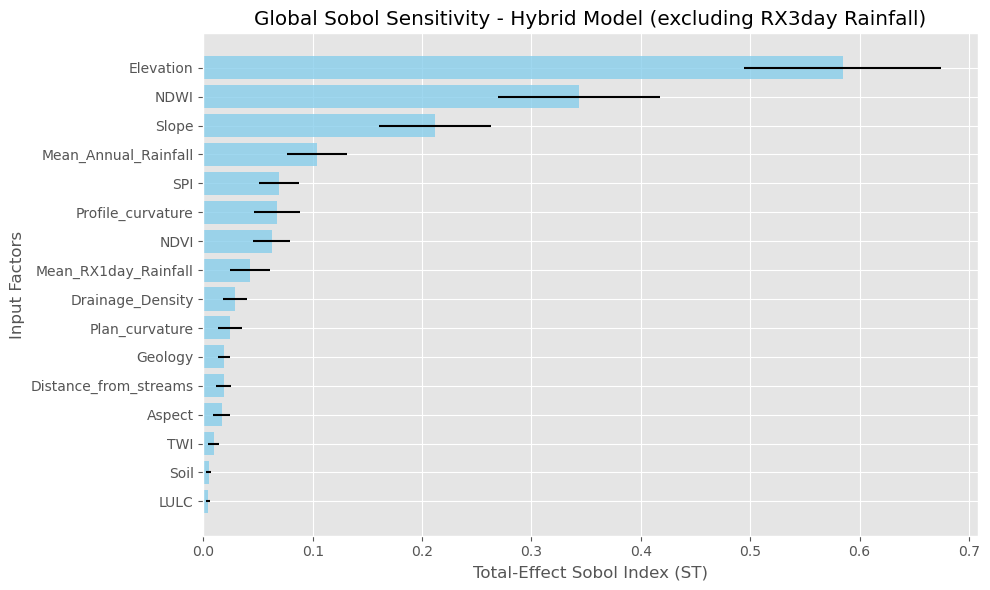

In [130]:
# ============================================================
# 🌍 Global Sobol Sensitivity Analysis (Hybrid Model)
# 🚫 Excluding "Mean_RX3day_Rainfall"
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol

# ---------------------------------------
# 1️⃣ Drop the unwanted factor
# ---------------------------------------
exclude_feature = "Mean_RX3day_Rainfall"

X_train_sobol = X_train.drop(columns=[exclude_feature])
feature_names = X_train_sobol.columns.tolist()

# Define bounds from your training data (min–max per feature)
X_min = X_train_sobol.min().values
X_max = X_train_sobol.max().values
bounds = np.column_stack([X_min, X_max]).tolist()

problem = {
    "num_vars": len(feature_names),
    "names": feature_names,
    "bounds": bounds
}

print("✅ Sobol problem defined (excluding RX3day):")
print("Number of variables:", problem["num_vars"])
print("Variables:", feature_names)

# ---------------------------------------
# 2️⃣ Define hybrid prediction (same as used before)
# ---------------------------------------
def hybrid_predict(X):
    """
    X: numpy array of shape (n_samples, n_features)
    Returns hybrid model's probability for class 1.
    """
    X_arr = np.array(X)

    # --- Align with original feature set (reinsert RX3day = median) ---
    X_full = pd.DataFrame(np.zeros((X_arr.shape[0], len(X_train.columns))),
                          columns=X_train.columns)

    # Fill available columns
    for col in feature_names:
        X_full[col] = X_arr[:, list(feature_names).index(col)]

    # Fill excluded RX3day with its median (neutral baseline)
    X_full[exclude_feature] = X_train[exclude_feature].median()

    # --- Now evaluate models (full feature order) ---
    p_rf  = model_rf.predict_proba(X_full)[:, 1]
    p_lr  = model_lr.predict_proba(X_full)[:, 1]
    p_ann = best_ann.predict_proba(X_full)[:, 1]

    X_imp    = imputer.transform(X_full)
    X_scaled = scaler.transform(X_imp)
    X_cnn    = X_scaled[..., np.newaxis]
    p_cnn    = model_cnn.predict(X_cnn, verbose=0).ravel()

    Z = np.column_stack([p_rf, p_lr, p_ann, p_cnn])
    p_hybrid = meta_lr.predict_proba(Z)[:, 1]
    return p_hybrid

# ---------------------------------------
# 3️⃣ Generate Sobol samples
# ---------------------------------------
N = 500  # base sample size (adjust if needed)
param_values = saltelli.sample(problem, N, calc_second_order=False)
print("Sobol sample shape:", param_values.shape)

# Evaluate hybrid model (Y = flood probability)
Y = hybrid_predict(param_values)
print("✅ Model evaluated. Y shape:", Y.shape)

# ---------------------------------------
# 4️⃣ Run Sobol Analysis
# ---------------------------------------
Si = sobol.analyze(problem, Y, calc_second_order=False, print_to_console=False)

# Extract S1 and ST
S1 = Si["S1"]
ST = Si["ST"]
S1_conf = Si["S1_conf"]
ST_conf = Si["ST_conf"]

sobol_df = pd.DataFrame({
    "Feature": feature_names,
    "S1": S1,
    "S1_conf": S1_conf,
    "ST": ST,
    "ST_conf": ST_conf
}).sort_values("ST", ascending=False)

print("\n📊 Global Sobol Sensitivity Results (excluding RX3day):")
print(sobol_df.to_string(index=False))

# ---------------------------------------
# 5️⃣ Plot Total-Effect (ST) Indices
# ---------------------------------------
plt.figure(figsize=(10, 6))
plt.barh(
    sobol_df["Feature"][::-1],
    sobol_df["ST"][::-1],
    xerr=sobol_df["ST_conf"][::-1],
    color="skyblue",
    alpha=0.8
)
plt.xlabel("Total-Effect Sobol Index (ST)")
plt.ylabel("Input Factors")
plt.title("Global Sobol Sensitivity - Hybrid Model (excluding RX3day Rainfall)")
plt.tight_layout()
#plt.savefig("Hybrid_Sobol_ST_no_RX3day.png", dpi=300, bbox_inches='tight')
plt.show()


In [132]:
from SALib.sample import saltelli
from SALib.analyze import sobol
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Define variables (exclude RX3day)
# -----------------------------
exclude_feature = "Mean_RX3day_Rainfall"

X_train_sobol = X_train.drop(columns=[exclude_feature])
feature_names = X_train_sobol.columns.tolist()

X_min = X_train_sobol.min().values
X_max = X_train_sobol.max().values
bounds = np.column_stack([X_min, X_max]).tolist()

problem = {
    "num_vars": len(feature_names),
    "names": feature_names,
    "bounds": bounds
}

print("Variables in Sobol (no RX3day):", feature_names)

# -----------------------------
# 2️⃣ Hybrid prediction wrapper
# -----------------------------
def hybrid_predict(X):
    """
    X: numpy array (n_samples, n_features_without_RX3day)
    returns: P(class=1) from hybrid model
    """
    X_arr = np.array(X)  # shape: (n_samples, D_no_rx3)

    # Rebuild full feature matrix in original order
    X_full = pd.DataFrame(
        np.zeros((X_arr.shape[0], X_train.shape[1])),
        columns=X_train.columns
    )

    # Fill all features except RX3day from the Sobol sample
    for j, col in enumerate(feature_names):
        X_full[col] = X_arr[:, j]

    # Set excluded RX3day to its median (fixed value)
    X_full[exclude_feature] = X_train[exclude_feature].median()

    # --- Base model predictions ---
    p_rf  = model_rf.predict_proba(X_full)[:, 1]
    p_lr  = model_lr.predict_proba(X_full)[:, 1]
    p_ann = best_ann.predict_proba(X_full)[:, 1]

    # CNN branch (with your imputer + scaler + reshape)
    X_imp    = imputer.transform(X_full)
    X_scaled = scaler.transform(X_imp)
    X_cnn    = X_scaled[..., np.newaxis]
    p_cnn    = model_cnn.predict(X_cnn, verbose=0).ravel()

    # Stack for meta-learner
    Z = np.column_stack([p_rf, p_lr, p_ann, p_cnn])
    p_hybrid = meta_lr.predict_proba(Z)[:, 1]
    return p_hybrid

# -----------------------------
# 3️⃣ Saltelli sampling (with 2nd order)
# -----------------------------
N = 500  # you can increase if it runs comfortably

param_values = saltelli.sample(problem, N, calc_second_order=True)
print("Sobol sample shape:", param_values.shape)

# Evaluate hybrid model on Sobol samples
Y = hybrid_predict(param_values)
print("Y shape:", Y.shape)

# -----------------------------
# 4️⃣ Sobol analysis (S1, S2, ST)
# -----------------------------
Si = sobol.analyze(
    problem,
    Y,
    calc_second_order=True,
    print_to_console=False
)

S1      = Si["S1"]
S1_conf = Si["S1_conf"]
ST      = Si["ST"]
ST_conf = Si["ST_conf"]
S2      = Si["S2"]
S2_conf = Si["S2_conf"]



Variables in Sobol (no RX3day): ['Aspect', 'Elevation', 'Slope', 'Profile_curvature', 'Plan_curvature', 'Mean_RX1day_Rainfall', 'Mean_Annual_Rainfall', 'NDVI', 'LULC', 'SPI', 'TWI', 'Soil', 'Geology', 'NDWI', 'Distance_from_streams', 'Drainage_Density']
Sobol sample shape: (17000, 16)
Y shape: (17000,)


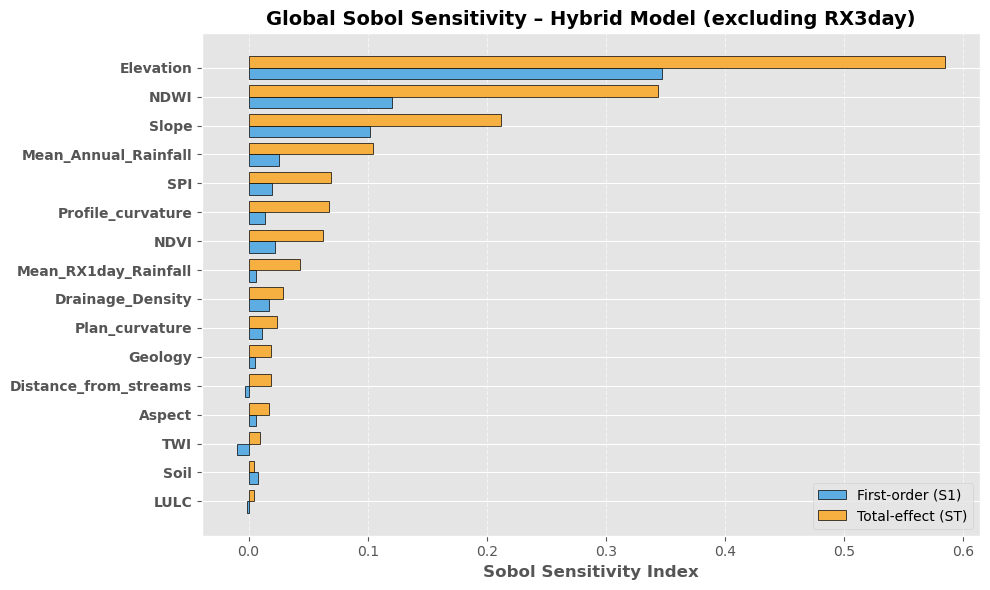

In [140]:
# ===============================================================
# 🌍 SOBOL SENSITIVITY VISUALIZATION
# ===============================================================
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- 1️⃣ Create clean DataFrame for S1 and ST ----------
sobol_df = pd.DataFrame({
    "Feature": feature_names,
    "First Order (S1)": S1,
    "Total Effect (ST)": ST
}).sort_values("Total Effect (ST)", ascending=True)

# ---------- 2️⃣ Matplotlib + Seaborn Horizontal Bar Plot ----------
plt.figure(figsize=(10, 6))
bar_width = 0.4
y = np.arange(len(sobol_df))

plt.barh(y - bar_width/2, sobol_df["First Order (S1)"], 
         height=bar_width, color="#5DADE2", label="First-order (S1)", edgecolor="black")
plt.barh(y + bar_width/2, sobol_df["Total Effect (ST)"], 
         height=bar_width, color="#F5B041", label="Total-effect (ST)", edgecolor="black")

plt.yticks(y, sobol_df["Feature"], fontsize=10, fontweight="bold")
plt.xlabel("Sobol Sensitivity Index", fontsize=12, fontweight="bold")
plt.title("Global Sobol Sensitivity – Hybrid Model (excluding RX3day)", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
#plt.savefig("Sobol_S1_ST_Barplot.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------- 3️⃣ Clean DataFrame for S2 ----------
S2_df = pd.DataFrame(S2, index=feature_names, columns=feature_names)
# Fill diagonal and symmetric NaNs for visualization
S2_plot = S2_df.copy()
for i in range(len(S2_plot)):
    for j in range(len(S2_plot)):
        if pd.isna(S2_plot.iloc[i, j]) and not pd.isna(S2_plot.iloc[j, i]):
            S2_plot.iloc[i, j] = S2_plot.iloc[j, i]
S2_plot = S2_plot.fillna(0)  # replace undefined diagonal NaN with 0




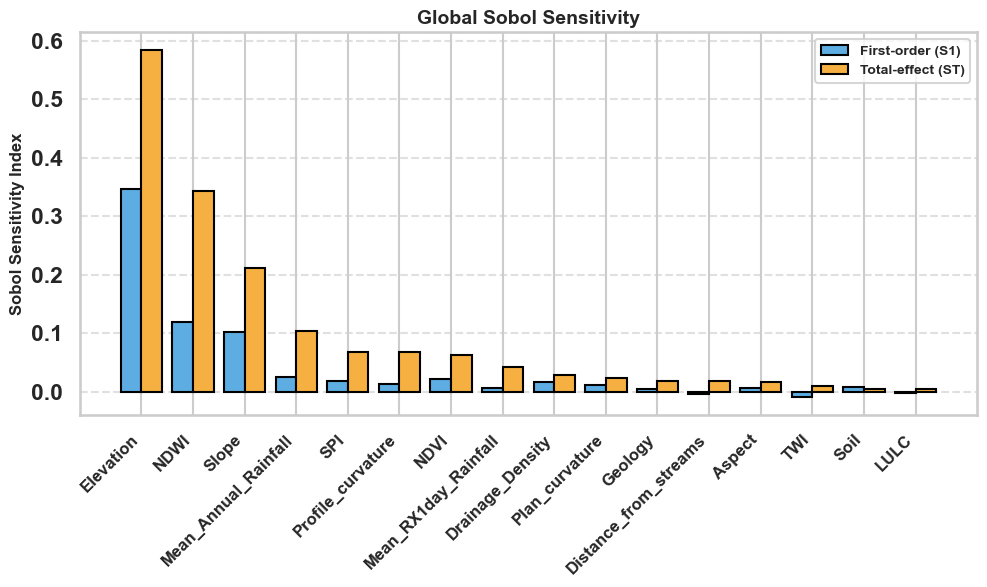

In [146]:
# ===============================================================
# 🌍 SOBOL SENSITIVITY VISUALIZATION (Vertical Version)
# ===============================================================
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- 🧱 Global Font Settings ----------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['font.weight'] = 'bold'
sns.set_style("whitegrid")

# ---------- 1️⃣ Create clean DataFrame for S1 and ST ----------
sobol_df = pd.DataFrame({
    "Feature": feature_names,
    "First Order (S1)": S1,
    "Total Effect (ST)": ST
}).sort_values("Total Effect (ST)", ascending=False)  # Largest first

# ---------- 2️⃣ Vertical Bar Plot (S1 vs ST) ----------
plt.figure(figsize=(10, 6))
bar_width = 0.4
x = np.arange(len(sobol_df))

# Bars
plt.bar(
    x - bar_width/2, sobol_df["First Order (S1)"],
    width=bar_width, color="#5DADE2", label="First-order (S1)", edgecolor="black"
)
plt.bar(
    x + bar_width/2, sobol_df["Total Effect (ST)"],
    width=bar_width, color="#F5B041", label="Total-effect (ST)", edgecolor="black"
)

# ---------- 3️⃣ Axis Labels & Title ----------
plt.xticks(x, sobol_df["Feature"], rotation=45, ha='right', fontsize=12, fontweight="bold")
plt.ylabel("Sobol Sensitivity Index", fontsize=12, fontweight="bold")
plt.title("Global Sobol Sensitivity", fontsize=14, fontweight="bold")

plt.legend(loc="upper right", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("C:/Users/Windows/Desktop/Climate Figures/Sobol_S1_ST_Vertical.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------- 3️⃣ Clean DataFrame for S2 ----------
S2_df = pd.DataFrame(S2, index=feature_names, columns=feature_names)
# Fill diagonal and symmetric NaNs for visualization
S2_plot = S2_df.copy()
for i in range(len(S2_plot)):
    for j in range(len(S2_plot)):
        if pd.isna(S2_plot.iloc[i, j]) and not pd.isna(S2_plot.iloc[j, i]):
            S2_plot.iloc[i, j] = S2_plot.iloc[j, i]
S2_plot = S2_plot.fillna(0)  # replace undefined diagonal NaN with 0


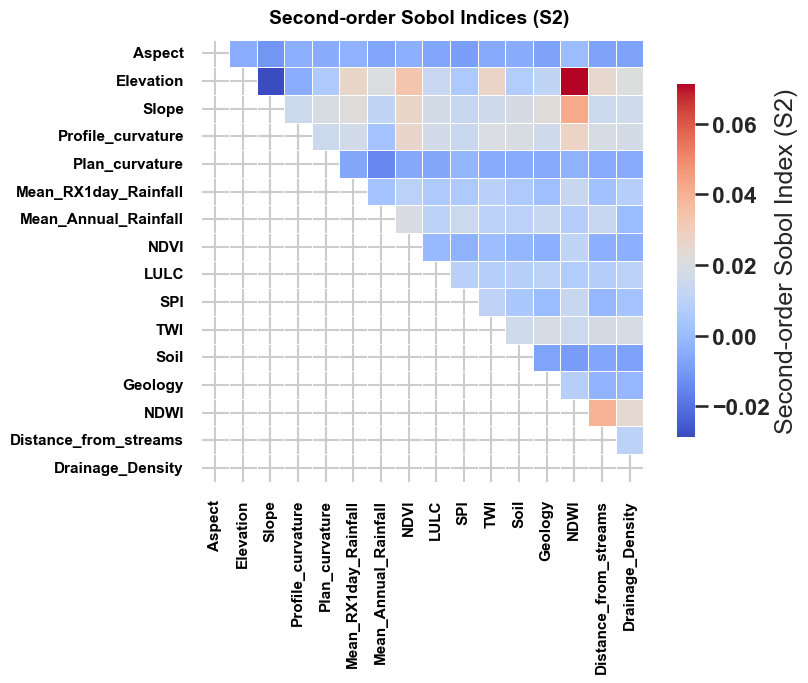

In [148]:
# ===============================================================
# 🌍 Second-order Sobol Indices (S2) – Heatmap (Enhanced)
# ===============================================================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ---------- 🧱 Global Font Settings ----------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 12

# ---------- 1️⃣ Heatmap Configuration ----------
plt.figure(figsize=(9, 7))

# Choose a high-contrast, scientific colormap
# Alternatives: "coolwarm", "RdYlBu_r", "Spectral_r", "plasma"
sns.heatmap(
    S2_df,
    cmap="coolwarm",          # smooth balanced gradient
    annot=False,              # turn on annot=True if you want numeric labels
    cbar_kws={"label": "Second-order Sobol Index (S2)", "shrink": 0.8},
    linewidths=0.5,
    square=True
)

# ---------- 2️⃣ Axis and Title Styling ----------
plt.xticks(
    ticks=np.arange(len(feature_names)) + 0.5,
    labels=feature_names,
    rotation=90,
    fontsize=11,
    fontweight="bold",
    color="black"
)
plt.yticks(
    ticks=np.arange(len(feature_names)) + 0.5,
    labels=feature_names,
    rotation=0,
    fontsize=11,
    fontweight="bold",
    color="black"
)

plt.title(
    "Second-order Sobol Indices (S2) ",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=12
)

# ---------- 3️⃣ Layout and Export ----------
plt.tight_layout()
plt.savefig("C:/Users/Windows/Desktop/Climate Figures/Hybrid_Sobol_S2_Heatmap_Enhanced.png", dpi=400, bbox_inches='tight')
plt.show()


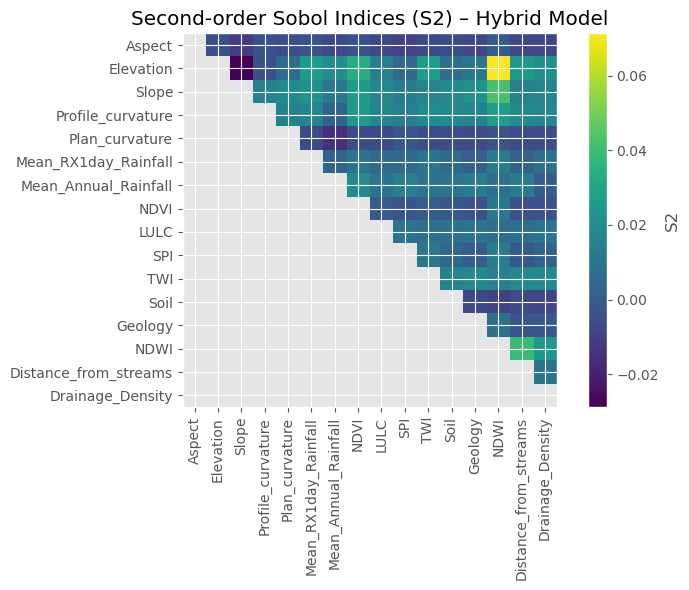

In [134]:
# Optional: quick heatmap for S2
plt.figure(figsize=(8, 6))
plt.imshow(S2_df, cmap="viridis")
plt.colorbar(label="S2")
plt.xticks(ticks=np.arange(len(feature_names)), labels=feature_names, rotation=90)
plt.yticks(ticks=np.arange(len(feature_names)), labels=feature_names)
plt.title("Second-order Sobol Indices (S2) – Hybrid Model")
plt.tight_layout()
plt.savefig("Hybrid_Sobol_S2_heatmap_no_RX3day.png", dpi=300, bbox_inches='tight')
plt.show()

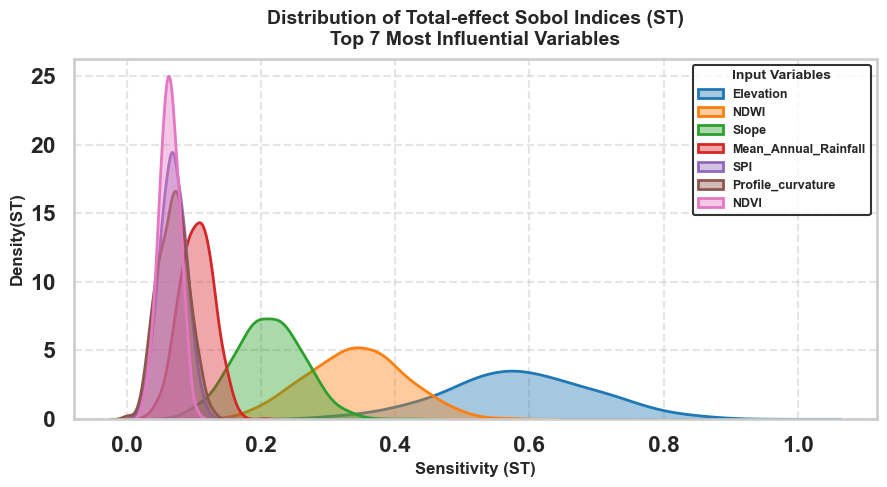

In [153]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ------------------ 🎯 Font & Style ------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# ------------------ 📊 Sort and Select Top 7 ------------------
sobol_df = pd.DataFrame({
    "Feature": feature_names,
    "ST": ST,
    "ST_conf": ST_conf
}).sort_values("ST", ascending=False)

top_n = 7
sobol_top = sobol_df.head(top_n)

# ------------------ 🎨 KDE for ST ------------------
n_samp = 1000
plt.figure(figsize=(9, 5))

# Use a bright, high-contrast palette
palette = sns.color_palette("tab10", top_n)

for i, row in enumerate(sobol_top.itertuples()):
    name = row.Feature
    mu = row.ST
    sigma = max(row.ST_conf, 1e-6)
    samples = np.random.normal(mu, sigma, n_samp)

    sns.kdeplot(
        samples,
        fill=True,
        alpha=0.4,
        linewidth=2,
        bw_adjust=1.2,
        color=palette[i],
        label=name
    )

# ------------------ 🧭 Axis & Aesthetic ------------------
plt.xlabel("Sensitivity (ST)", fontsize=12, fontweight="bold")
plt.ylabel("Density(ST)", fontsize=12, fontweight="bold")
plt.title("Distribution of Total-effect Sobol Indices (ST)\nTop 7 Most Influential Variables",
          fontsize=14, fontweight="bold", pad=10)

plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(
    loc="upper right",
    fontsize=9,
    title="Input Variables",
    title_fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)
plt.tight_layout()
plt.savefig("C:/Users/Windows/Desktop/Climate Figures/Sobol_ST_KDE_Top7.png", dpi=800, bbox_inches="tight")
plt.show()


The end